<a href="https://colab.research.google.com/github/eduardmendoza92/Mendoza1706062013Parcial4/blob/main/Parcial04_E_Asociacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
from itertools import combinations
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [5]:
url = "https://raw.githubusercontent.com/eduardmendoza92/Mendoza1706062013Parcial4/refs/heads/main/data/raw/clave_E_asociacion.csv"

In [6]:
df = pd.read_csv(url)
print("Dataset Cargado Correctamente")

Dataset Cargado Correctamente


In [7]:
print(df.shape)
#Identificar la cantidad de registros y la cantidad de columnas que este dataset
#contiene

(605, 7)


In [8]:
print(df.head())
#El dataset representa un registro de transacciones comerciales u operaciones de
#venta detalladas a nivel de artículo. Al observar las primeras 5 líneas de la muestra,
#se identifican las siguientes variables y su comportamiento inicial

  transaccion_id cliente_id       fecha  categoria         item  cantidad  \
0        E-T0001    E-C0068  2026-01-01    Tecnico  Calculadora         1   
1        E-T0001    E-C0068  2026-01-01     Libros       Novela         1   
2        E-T0001    E-C0068  2026-01-01       Arte     Pinceles         1   
3        E-T0001    E-C0068  2026-01-01    Tecnico        Regla         1   
4        E-T0002    E-C0056  2026-01-22  Papeleria        Lapiz         1   

  canal  
0   App  
1   App  
2   App  
3   App  
4   Web  


In [9]:
print(df.info())
#El dataset cuenta con 6 variables de tipo objeto (object)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaccion_id  605 non-null    object
 1   cliente_id      605 non-null    object
 2   fecha           605 non-null    object
 3   categoria       605 non-null    object
 4   item            605 non-null    object
 5   cantidad        605 non-null    int64 
 6   canal           604 non-null    object
dtypes: int64(1), object(6)
memory usage: 33.2+ KB
None


In [10]:
print(df.isnull().sum())
#Casi todas las variables tienen una integridad del 100% (0 nulos), a excepción de la columna canal, la cual reporta 1 valor nulo

transaccion_id    0
cliente_id        0
fecha             0
categoria         0
item              0
cantidad          0
canal             1
dtype: int64


In [13]:
print(df.duplicated().sum())
#La función arroja que existe 1 registro completamente duplicado (una fila idéntica en todas sus columnas a otra presente en el dataset).

1


In [15]:
# Limpieza previa esencial para evitar sesgos en las reglas
# Eliminamos el registro duplicado exacto y la fila que tiene nulo en la columna 'canal'
df_clean = df.drop_duplicates().dropna(subset=['canal']).copy()

In [16]:
print("--- DIMENSIONES Y CONTROL DE CALIDAD ---")
print(f"Dimensiones originales: {df.shape}")
print(f"Dimensiones tras limpieza: {df_clean.shape}\n")

--- DIMENSIONES Y CONTROL DE CALIDAD ---
Dimensiones originales: (605, 7)
Dimensiones tras limpieza: (603, 7)



In [26]:
# Para aplicar Apriori, necesitamos transformar el dataset de un formato "largo"
# (un artículo por fila) a un formato "ancho/matriz" (una transacción por fila,
# y los artículos como columnas con valores 1 o 0 / True o False).

# Agrupamos por transaccion_id e item, sumamos las cantidades y desapilamos (unstack)
# Rellenamos con 0 los artículos que no se compraron en esa transacción específica.
basket = (df_clean.groupby(['transaccion_id', 'item'])['cantidad']
          .sum().unstack().reset_index()
          .fillna(0)
          .set_index('transaccion_id'))

In [27]:
# Codificamos los valores: Cualquier cantidad >= 1 será True (o 1), y 0 será False (o 0).
def encode_units(x):
    if x <= 0:
        return False
    if x >= 1:
        return True

basket_sets = basket.applymap(encode_units)

print(f"Dimensiones de la matriz transaccional: {basket_sets.shape}")
print("Muestra de la matriz de asociación:")
print(basket_sets.head(3))

Dimensiones de la matriz transaccional: (184, 20)
Muestra de la matriz de asociación:
item            Acuarelas  Borrador  Calculadora  Cartulina  Clips  Compas  \
transaccion_id                                                               
E-T0001             False     False         True      False  False   False   
E-T0002             False     False        False      False  False   False   
E-T0003             False     False         True      False   True   False   

item            Cuaderno  Diccionario  Engrapadora  Folder  Lapicero  Lapiz  \
transaccion_id                                                                
E-T0001            False        False        False   False     False  False   
E-T0002            False        False        False   False     False   True   
E-T0003            False        False        False   False     False  False   

item            Libro_matematica  Libro_programacion  Marcadores  Memoria_USB  \
transaccion_id                                

/tmp/ipykernel_36578/3121211945.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(encode_units)


In [30]:
# Definimos un soporte mínimo. Como el dataset es pequeño (603 registros totales,
# lo que equivale a menos transacciones únicas), usaremos un min_support bajo (ej. 2% o 5%)
# para asegurarnos de capturar patrones interesantes.
min_soporte = 0.03

# 5.1 Encontrar conjuntos de elementos frecuentes
frequent_itemsets = apriori(basket_sets, min_support=min_soporte, use_colnames=True)
print(f"\n--- Conjuntos de ítems frecuentes encontrados: {len(frequent_itemsets)} ---")

# 5.2 Generar las reglas de asociación basadas en la métrica 'lift' (o confianza)
# Usamos un umbral mínimo de lift > 1 para garantizar que la regla aporte valor predictivo.
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Ordenamos las reglas por 'lift' y luego por 'confidence' de manera descendente
rules = rules.sort_values(by=['lift', 'confidence'], ascending=[False, False])


# ==============================================================================
# 7. MOSTRAR LAS 10 REGLAS MÁS RELEVANTES
# ==============================================================================
print("\n--- TOP 10 REGLAS DE ASOCIACIÓN MÁS RELEVANTES ---")
top_10_rules = rules.head(10)[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

# Formateamos la visualización para que los frozensets sean legibles
top_10_rules['antecedents'] = top_10_rules['antecedents'].apply(lambda x: list(x))
top_10_rules['consequents'] = top_10_rules['consequents'].apply(lambda x: list(x))

print(top_10_rules.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


--- Conjuntos de ítems frecuentes encontrados: 81 ---

--- TOP 10 REGLAS DE ASOCIACIÓN MÁS RELEVANTES ---
           antecedents            consequents  support  confidence     lift
  [Lapicero, Cuaderno]           [Resaltador] 0.092391    0.850000 5.045161
          [Resaltador]   [Lapicero, Cuaderno] 0.092391    0.548387 5.045161
  [Cuaderno, Borrador]           [Resaltador] 0.038043    0.777778 4.616487
          [Resaltador]   [Cuaderno, Borrador] 0.038043    0.225806 4.616487
            [Cuaderno]   [Lapicero, Borrador] 0.032609    0.139535 4.279070
  [Lapicero, Borrador]             [Cuaderno] 0.032609    1.000000 4.279070
[Resaltador, Borrador]             [Cuaderno] 0.038043    1.000000 4.279070
            [Cuaderno] [Resaltador, Borrador] 0.038043    0.162791 4.279070
     [Pinceles, Regla]            [Acuarelas] 0.038043    0.777778 3.867868
           [Acuarelas]      [Pinceles, Regla] 0.038043    0.189189 3.867868


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

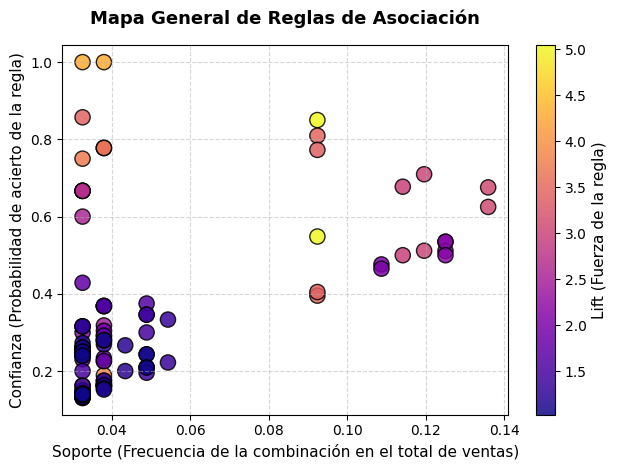

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [33]:
# Asegurar que las reglas tengan un nombre legible combinando Antecedentes -> Consecuentes
# Convertimos los frozensets de mlxtend a cadenas de texto limpias
rules['rule_name'] = (
    rules['antecedents'].apply(lambda x: ', '.join(list(x))) +
    ' -> ' +
    rules['consequents'].apply(lambda x: ', '.join(list(x)))
)

# ==============================================================================
# GRÁFICO 1: MAPA DE DISPERSIÓN DE REGLAS (SOPORTE VS CONFIANZA)
# ==============================================================================
plt.clf()  # Limpiar figuras previas

# Creamos el gráfico de dispersión utilizando el Lift para la escala de colores
sc = plt.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='plasma',
    alpha=0.85,
    s=120,
    edgecolor='black'
)

# Configuración de barra de colores y etiquetas
cbar = plt.colorbar(sc)
cbar.set_label('Lift (Fuerza de la regla)', fontsize=11)

plt.xlabel('Soporte (Frecuencia de la combinación en el total de ventas)', fontsize=11)
plt.ylabel('Confianza (Probabilidad de acierto de la regla)', fontsize=11)
plt.title('Mapa General de Reglas de Asociación', fontsize=13, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Guardar el gráfico
plt.savefig('scatter_reglas.png', dpi=150)